# Model Comparison — All 4 Algorithms
**Run this notebook LAST, after all 4 member notebooks have been executed.**

Compares: Isolation Forest · DBSCAN · Random Forest · XGBoost  
Dataset: NSL-KDD (`nsl_kdd_dataset.csv`)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 2. Load Individual Results

In [2]:
result_files = [
    'results_isolation_forest.csv',
    'results_dbscan.csv',
    'results_random_forest.csv',
    'results_xgboost.csv',
]

dfs = []
for fname in result_files:
    path = os.path.join('.', fname)
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
        print(f'Loaded : {fname}')
    else:
        print(f'MISSING: {fname} — run the corresponding member notebook first.')

results_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f'\nTotal algorithms loaded: {len(dfs)}')

Loaded : results_isolation_forest.csv
Loaded : results_dbscan.csv
Loaded : results_random_forest.csv
Loaded : results_xgboost.csv

Total algorithms loaded: 4


## 3. Manual Fallback
If CSVs are not yet available, paste your actual metric values below.

In [3]:
# UNCOMMENT and fill in your actual values if CSVs are missing

# results_df = pd.DataFrame([
#     {'Algorithm':'Isolation Forest','Type':'Unsupervised',
#      'Accuracy':'N/A','Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00},
#     {'Algorithm':'DBSCAN',          'Type':'Unsupervised',
#      'Accuracy':'N/A','Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':'N/A'},
#     {'Algorithm':'Random Forest',   'Type':'Supervised',
#      'Accuracy':0.00, 'Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00},
#     {'Algorithm':'XGBoost',         'Type':'Supervised',
#      'Accuracy':0.00, 'Precision':0.00,'Recall':0.00,'F1 Score':0.00,'ROC-AUC':0.00},
# ])

print('Manual fallback cell ready (uncomment if needed).')

Manual fallback cell ready (uncomment if needed).


## 4. Full Comparison Table

In [4]:
display_cols = [c for c in ['Algorithm','Type','Accuracy',
                             'Precision','Recall','F1 Score','ROC-AUC']
                if c in results_df.columns]

print('=== Comparison Table ===')
print(results_df[display_cols].to_string(index=False))

=== Comparison Table ===
       Algorithm         Type  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Isolation Forest Unsupervised       NaN     0.7956  0.5106    0.6220   0.4915
          DBSCAN Unsupervised       NaN     0.0000  0.0000    0.0000      NaN
   Random Forest   Supervised    0.8002     0.8002  1.0000    0.8890   0.5119
         XGBoost   Supervised    0.7810     0.7984  0.9718    0.8766   0.4913


## 5. F1 Score Bar Chart

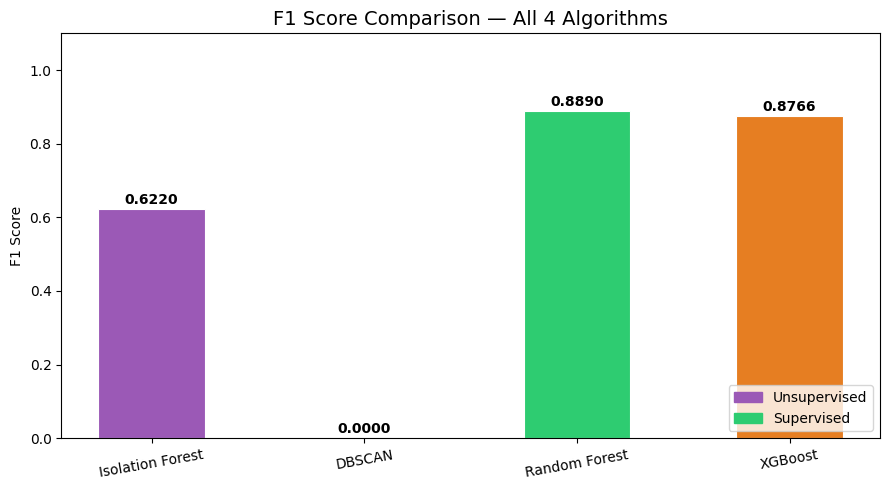

In [5]:
algo_colors = {
    'Isolation Forest': '#9b59b6',
    'DBSCAN'          : '#3498db',
    'Random Forest'   : '#2ecc71',
    'XGBoost'         : '#e67e22'
}
colors = [algo_colors.get(a, '#95a5a6') for a in results_df['Algorithm']]
f1_vals = pd.to_numeric(results_df['F1 Score'], errors='coerce')

plt.figure(figsize=(9, 5))
bars = plt.bar(results_df['Algorithm'], f1_vals,
               color=colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, f1_vals):
    if not pd.isna(val):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
plt.title('F1 Score Comparison — All 4 Algorithms', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=10)
u_patch = mpatches.Patch(color='#9b59b6', label='Unsupervised')
s_patch = mpatches.Patch(color='#2ecc71', label='Supervised')
plt.legend(handles=[u_patch, s_patch], loc='lower right')
plt.tight_layout()
plt.savefig('comparison_f1.png', dpi=150)
plt.show()

## 6. Grouped Bar Chart — Precision, Recall, F1

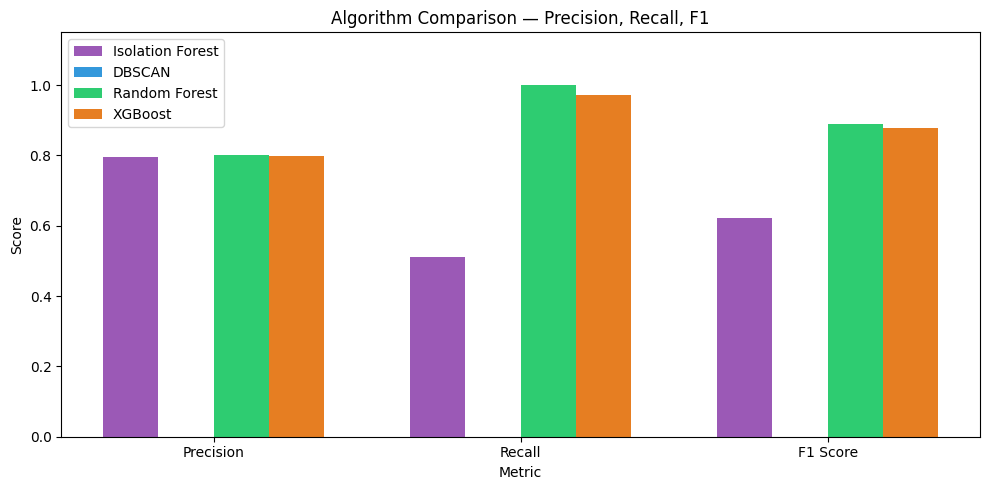

In [6]:
metrics   = ['Precision', 'Recall', 'F1 Score']
x         = np.arange(len(metrics))
bar_width = 0.18
algos     = results_df['Algorithm'].tolist()
color_list= [algo_colors.get(a, '#95a5a6') for a in algos]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [pd.to_numeric(row.get(m, np.nan), errors='coerce') for m in metrics]
    ax.bar(x + i * bar_width, vals, bar_width,
           label=row['Algorithm'], color=color_list[i])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Algorithm Comparison — Precision, Recall, F1')
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig('comparison_grouped_bar.png', dpi=150)
plt.show()

## 7. ROC-AUC Comparison (Supervised Only)

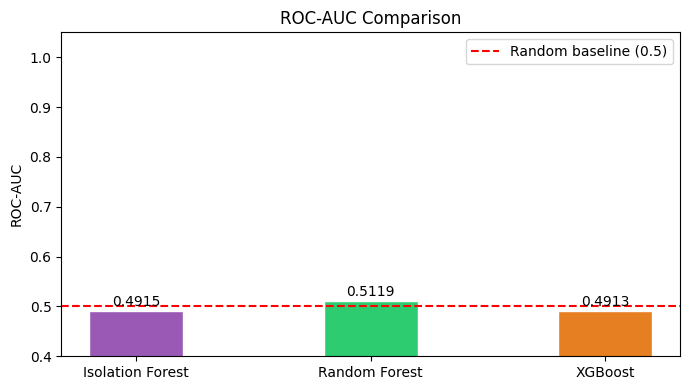

In [7]:
roc_df = results_df.copy()
roc_df['ROC-AUC'] = pd.to_numeric(roc_df['ROC-AUC'], errors='coerce')
roc_df = roc_df.dropna(subset=['ROC-AUC'])

if not roc_df.empty:
    c = [algo_colors.get(a, '#95a5a6') for a in roc_df['Algorithm']]
    plt.figure(figsize=(7, 4))
    bars = plt.bar(roc_df['Algorithm'], roc_df['ROC-AUC'],
                   color=c, edgecolor='white', width=0.4)
    for bar, val in zip(bars, roc_df['ROC-AUC']):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    plt.axhline(y=0.5, color='red', linestyle='--', label='Random baseline (0.5)')
    plt.ylim(0.4, 1.05)
    plt.ylabel('ROC-AUC')
    plt.title('ROC-AUC Comparison')
    plt.legend()
    plt.tight_layout()
    plt.savefig('comparison_roc_auc.png', dpi=150)
    plt.show()
else:
    print('No numeric ROC-AUC values available.')

## 8. Performance Heatmap

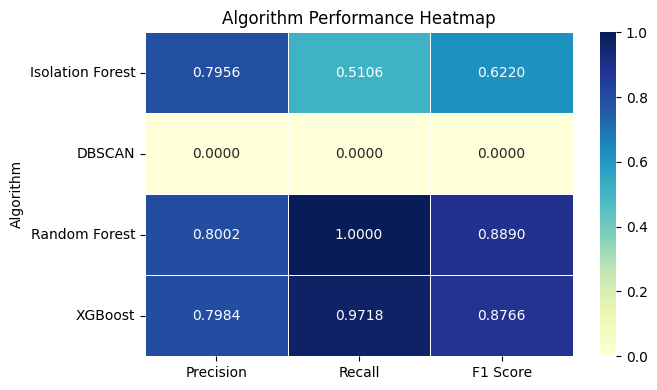

In [8]:
heatmap_metrics = ['Precision', 'Recall', 'F1 Score']
hmap = results_df.set_index('Algorithm')[heatmap_metrics]\
                 .apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(7, 4))
sns.heatmap(hmap, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Algorithm Performance Heatmap')
plt.tight_layout()
plt.savefig('comparison_heatmap.png', dpi=150)
plt.show()

## 9. Discussion Points for Report

In [9]:
print("""
=== KEY DISCUSSION POINTS ===

1. SUPERVISED vs UNSUPERVISED GAP
   Random Forest and XGBoost use labelled data during training,
   so they typically outperform unsupervised methods on labelled benchmarks.
   Isolation Forest and DBSCAN receive NO labels — they detect anomalies
   purely from data distribution.

2. ISOLATION FOREST
   Pros  : Fast O(n log n), single contamination parameter, no PCA needed.
   Cons  : Contamination must be estimated; may struggle with large attack
           clusters (e.g., DoS floods) that are not truly isolated.

3. DBSCAN
   Pros  : Discovers clusters of arbitrary shape; no assumption on anomaly
           fraction; noise points are naturally the anomalies.
   Cons  : Sensitive to eps and min_samples; requires dimensionality
           reduction (PCA) first; binary cluster/noise decision.

4. RANDOM FOREST
   Pros  : Robust to overfitting via bagging; built-in feature importance;
           handles class imbalance with class_weight='balanced'.
   Cons  : Larger memory footprint; slower inference than XGBoost at scale.

5. XGBOOST
   Pros  : State-of-the-art performance on tabular data; built-in L1/L2
           regularisation; SHAP explainability; handles imbalance via
           scale_pos_weight.
   Cons  : More hyperparameters to tune; risk of overfitting if not
           regularised properly.

6. METRICS IN CONTEXT (Intrusion Detection)
   Recall   : Critical — missing a real attack is dangerous.
   Precision: Prevents alert fatigue — too many false alarms burn analyst time.
   F1       : Harmonic mean — best single summary when both matter.
   ROC-AUC  : Threshold-independent discrimination quality.

7. DATASET NOTE
   The CSV has 4430 rows with features already scaled to [0,1].
   Labels: normal, DoS, Probe, R2L, U2R.
   Binary classification: normal=0, all attacks=1.

8. FUTURE WORK
   - Multi-class classification (distinguish specific attack types).
   - Hybrid: use unsupervised anomaly scores as an extra feature
     for supervised models.
   - Test on larger/newer datasets (CICIDS-2017, UNSW-NB15).
   - Real-time streaming anomaly detection.
""")


=== KEY DISCUSSION POINTS ===

1. SUPERVISED vs UNSUPERVISED GAP
   Random Forest and XGBoost use labelled data during training,
   so they typically outperform unsupervised methods on labelled benchmarks.
   Isolation Forest and DBSCAN receive NO labels — they detect anomalies
   purely from data distribution.

2. ISOLATION FOREST
   Pros  : Fast O(n log n), single contamination parameter, no PCA needed.
   Cons  : Contamination must be estimated; may struggle with large attack
           clusters (e.g., DoS floods) that are not truly isolated.

3. DBSCAN
   Pros  : Discovers clusters of arbitrary shape; no assumption on anomaly
           fraction; noise points are naturally the anomalies.
   Cons  : Sensitive to eps and min_samples; requires dimensionality
           reduction (PCA) first; binary cluster/noise decision.

4. RANDOM FOREST
   Pros  : Robust to overfitting via bagging; built-in feature importance;
           handles class imbalance with class_weight='balanced'.
   Con

## 10. Export Final Comparison Table

In [10]:
results_df.to_csv('final_comparison_table.csv', index=False)
print('Saved: final_comparison_table.csv')
print()
print(results_df[display_cols].to_string(index=False))

Saved: final_comparison_table.csv

       Algorithm         Type  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Isolation Forest Unsupervised       NaN     0.7956  0.5106    0.6220   0.4915
          DBSCAN Unsupervised       NaN     0.0000  0.0000    0.0000      NaN
   Random Forest   Supervised    0.8002     0.8002  1.0000    0.8890   0.5119
         XGBoost   Supervised    0.7810     0.7984  0.9718    0.8766   0.4913
